# 05 — Atlantic Regional Model

**Dataset:** Global Coral Bleaching Database 1980–2020 (van Woesik & Kratochwill 2022)  
**Input:** `bleaching_feature_selection.csv` filtered to Atlantic Ocean only  
**Target variable:** `Bleaching_Binary` (none / bleaching)

---

## Contents

1. Data filtering and class distribution
   - 1.1 Class distribution
2. Temporal train/validation/test split
3. Preprocessing pipeline
4. Random Forest + SMOTE
   - 4.1 Baseline model
   - 4.1.1 Atlantic baseline results
   - 4.2 Tuning results — final model selection
5. Model interpretability: SHAP
   - 5.1 Substrate Name Ablation
   - 5.1.1 Ablation results
6. Error analysis
   - 6.1 Error analysis results
7. Model saving
8. Dashboard Data Export

---

## Key methodological decisions

- **Geographic filter:** Atlantic Ocean only (13,087 observations, 40% of global dataset).
- **Motivation:** the global model (notebook 04) showed a structural geographic bias.
  Atlantic false negative rate was 0.19 vs 0.74 for the Central Indo-Pacific.
  SHAP analysis confirmed the model was learning geography rather than thermal physics.
  The root cause is temporal: Pacific major bleaching events (2016, 2020, 2022, 2024)
  fall outside the training window. The Atlantic dataset is temporally balanced,
  with major events in 1998 and 2005 both within the training period.
- **Temporal split:** train 1980–2009, validation 2010–2014, test 2015–2019.
- **Target:** binary classification (none vs bleaching).
- **Primary metric:** recall — missing a bleaching event carries higher ecological
  cost than a false alarm.
- **Secondary metric:** F1-score.
- **Final model:** Random Forest without `Substrate_Name` and without geographic coordinates (`max_depth=6`,
  `min_samples_leaf=5`, `n_estimators=100`, `max_features='sqrt'`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
import shap
import joblib
import os

pd.set_option('display.max_columns', None)

In [2]:
# Project colour palette: ocean themed 🌊
color_primary = 'teal'
color_secondary = 'coral'  
color_accent = 'turquoise'

In [3]:
# Load feature-selected dataset
df = pd.read_csv('../data/processed/bleaching_feature_selection.csv', low_memory=False)

In [4]:
# Remap target to binary
df['Bleaching_Binary'] = df['Bleaching_Category'].apply(
    lambda x: 'none' if x == 'none' else 'bleaching'
)

## 1. Data filtering and class distribution 

In [5]:
# Filter to Atlantic ocean only
df_atlantic = df[df['Ocean_Name'] == 'Atlantic'].copy()

print(f"Atlantic dataset shape: {df_atlantic.shape}")
print(f"\nClass distribution:")
print(df_atlantic['Bleaching_Binary'].value_counts())
print(f"\nClass percentages:")
print(df_atlantic['Bleaching_Binary'].value_counts(normalize=True).round(3))

Atlantic dataset shape: (13087, 28)

Class distribution:
Bleaching_Binary
none         8930
bleaching    4157
Name: count, dtype: int64

Class percentages:
Bleaching_Binary
none         0.682
bleaching    0.318
Name: proportion, dtype: float64


### 1.1 Class Distribution

The Atlantic subset contains 13,087 observations. The class distribution is 
significantly more balanced than the global dataset:

- Global: 82% none / 18% bleaching
- Atlantic: 68% none / 32% bleaching

Class imbalance is still present and will be handled with SMOTE, 
but the minority class is nearly twice as represented as in the global model.
This should improve the model's ability to detect bleaching events.

In [6]:
# 'Ocean_Name' is not included in cat_cols: its value is constant for the Atlantic model
# and carries no meaningful information.
# 'Latitude_Degrees' and 'Longitude_Degrees' are excluded from num_cols intentionally:
# including geographic coordinates would allow the model to learn location as a proxy
# for bleaching risk rather than the underlying thermal physics. The goal is a model
# that generalises from environmental variables, not one that memorises geography.
num_cols = [
    'Distance_to_Shore', 'Turbidity', 'Cyclone_Frequency', 'Date_Month',
    'Date_Year', 'Depth_m', 'ClimSST', 'Temperature_Kelvin', 'Temperature_Mean',
    'Temperature_Maximum', 'Windspeed', 'SSTA', 'SSTA_DHW',
    'TSA', 'TSA_Maximum', 'TSA_Mean', 'TSA_Frequency',
    'TSA_DHW', 'TSA_DHWMax', 'TSA_DHWMean'
]

cat_cols = ['Realm_Name', 'Substrate_Name', 'Exposure']

target = 'Bleaching_Binary'

## 2. Temporal Train/Validation/Test split

Same split as the global model (notebook 04): train 1980–2009, 
validation 2010–2014, test 2015–2019. Both major Atlantic bleaching 
events (1998 and 2005) fall within the training window.

In [7]:
# Splitting the dataset into training, validation and testing subsets
train = df_atlantic[df_atlantic['Date_Year'] <= 2009]
validation = df_atlantic[(df_atlantic['Date_Year'] >= 2010) & (df_atlantic['Date_Year'] <= 2014)]
test = df_atlantic[df_atlantic['Date_Year'] >= 2015]

X_train = train.drop(columns=['Bleaching_Category', 'Bleaching_Binary'])
y_train = train['Bleaching_Binary']

X_val = validation.drop(columns=['Bleaching_Category', 'Bleaching_Binary'])
y_val = validation['Bleaching_Binary']

X_test = test.drop(columns=['Bleaching_Category', 'Bleaching_Binary'])
y_test = test['Bleaching_Binary']

print(f"Train:      {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test:       {X_test.shape}")

Train:      (9742, 26)
Validation: (2099, 26)
Test:       (1246, 26)


## 3. Preprocessing Pipeline

We build a preprocessing pipeline using `ColumnTransformer` from sklearn,
following the same approach as notebook 04.

This applies two transformations in parallel:
- `StandardScaler` on numerical columns
- `OneHotEncoder` on categorical columns

The pipeline is fitted on the training set only, then applied to validation and test.
This prevents data leakage from future observations into the training process.

In [8]:
# Preprocessing pipeline: StandardScaler for numerical columns, OneHotEncoder for categorical columns
# The pipeline is fitted on the training set only to prevent data leakage
preprocessor_atl = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
])

In [9]:
# Fit on train only, then transform all three sets
X_train_processed = preprocessor_atl.fit_transform(X_train)
X_val_processed = preprocessor_atl.transform(X_val)
X_test_processed = preprocessor_atl.transform(X_test)

print(f"Train processed:      {X_train_processed.shape}")
print(f"Validation processed: {X_val_processed.shape}")
print(f"Test processed:       {X_test_processed.shape}")

Train processed:      (9742, 26)
Validation processed: (2099, 26)
Test processed:       (1246, 26)


## 4. Random Forest + SMOTE

### 4.1 Baseline model

We first train a vanilla Random Forest with SMOTE to establish a baseline 
for the Atlantic regional model. Parameters are kept minimal to allow 
comparison with the global model baseline.

In [10]:
# SMOTE to handle class imbalance
X_train_smote, y_train_smote = SMOTE(random_state=42).fit_resample(
    X_train_processed, y_train
)

print("After SMOTE:")
print(y_train_smote.value_counts())

After SMOTE:
Bleaching_Binary
bleaching    6535
none         6535
Name: count, dtype: int64


In [11]:
# Vanilla Random Forest — baseline
rf_atl = RandomForestClassifier(
    max_depth=10,
    min_samples_leaf=5,
    random_state=42
)

rf_atl.fit(X_train_smote, y_train_smote)
y_pred_atl = rf_atl.predict(X_val_processed)

print(classification_report(y_val, y_pred_atl))

              precision    recall  f1-score   support

   bleaching       0.56      0.72      0.63       564
        none       0.89      0.79      0.83      1535

    accuracy                           0.77      2099
   macro avg       0.72      0.76      0.73      2099
weighted avg       0.80      0.77      0.78      2099



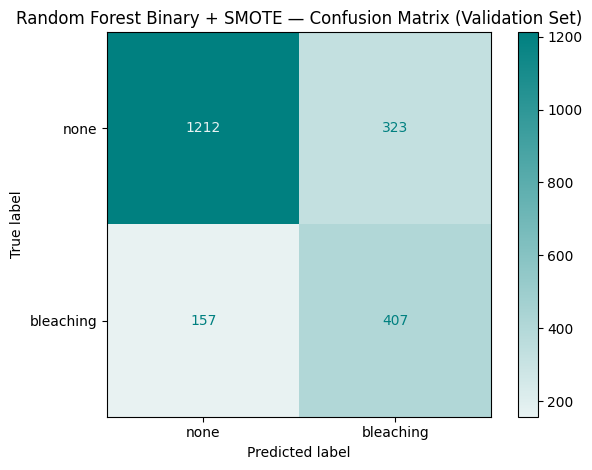

In [12]:
cm = confusion_matrix(y_val, y_pred_atl, labels=['none', 'bleaching'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['none', 'bleaching'])

disp.plot(cmap=sns.light_palette(color_primary, as_cmap=True))
plt.title('Random Forest Binary + SMOTE — Confusion Matrix (Validation Set)')
plt.tight_layout()
plt.savefig('../outputs/figures/cm_atlantic_baseline.png', bbox_inches='tight', dpi=150)
plt.show()

### 4.1.1 Atlantic Baseline Results

| Model | Recall (bleaching) | Precision (bleaching) | Macro F1 | Accuracy |
|---|---|---|---|---|
| Global RF + SMOTE | 0.61 | 0.47 | 0.73 | 0.86 |
| Atlantic RF vanilla | **0.72** | 0.56 | 0.73 | 0.77 |

Recall on bleaching events improves from 0.61 to 0.72 without any tuning: 
a significant gain from filtering to the Atlantic region alone.

The overall accuracy drops from 0.86 to 0.77, driven by more false positives 
on the `none` class (recall none: 0.90 → 0.79). This is the expected trade-off: 
a model that is more sensitive to bleaching events will generate more false alarms 
on healthy reefs. Ecologically, this is the right direction: missing a bleaching 
event is more costly than a false positive alarm.

The macro F1 is essentially unchanged (0.73 → 0.73), confirming that the gain 
in bleaching recall is real and not at the expense of overall model quality.

**Next step:** apply the optimal parameters from notebook 04 
(`max_depth=6`, `min_samples_leaf=5`, `n_estimators=200`, `max_features='sqrt'`) 
and check if recall improves further.

In [13]:
# Manual tuning using the optimised parameters found in Notebook 04
rf_manual = RandomForestClassifier(
    max_depth=6,           
    min_samples_leaf=5,    
    n_estimators=200,     
    max_features='sqrt',  
    random_state=42
)

rf_manual.fit(X_train_smote, y_train_smote)
y_pred_manual = rf_manual.predict(X_val_processed)

print(classification_report(y_val, y_pred_manual))

              precision    recall  f1-score   support

   bleaching       0.48      0.79      0.60       564
        none       0.90      0.69      0.78      1535

    accuracy                           0.72      2099
   macro avg       0.69      0.74      0.69      2099
weighted avg       0.79      0.72      0.73      2099



In [14]:
# Manual tuning experiment 2 - Testing max_depth=8
rf_manual_2 = RandomForestClassifier(
    max_depth=8,
    min_samples_leaf=5,
    n_estimators=200,
    max_features='sqrt',
    random_state=42
)

rf_manual_2.fit(X_train_smote, y_train_smote)
y_pred_manual_2 = rf_manual_2.predict(X_val_processed)

print(classification_report(y_val, y_pred_manual_2))

              precision    recall  f1-score   support

   bleaching       0.53      0.75      0.62       564
        none       0.89      0.76      0.82      1535

    accuracy                           0.76      2099
   macro avg       0.71      0.76      0.72      2099
weighted avg       0.80      0.76      0.77      2099



In [15]:
# Manual tuning 3 - Testing n_estimators=100
rf_manual_3 = RandomForestClassifier(
    max_depth=6,
    min_samples_leaf=5,
    n_estimators=100,
    max_features='sqrt',
    random_state=42
)
rf_manual_3.fit(X_train_smote, y_train_smote)
y_pred_manual_3 = rf_manual_3.predict(X_val_processed)
print("n_estimators=100:")
print(classification_report(y_val, y_pred_manual_3))

n_estimators=100:
              precision    recall  f1-score   support

   bleaching       0.48      0.80      0.60       564
        none       0.90      0.68      0.78      1535

    accuracy                           0.71      2099
   macro avg       0.69      0.74      0.69      2099
weighted avg       0.79      0.71      0.73      2099



In [16]:
# Manual tuning 4 - Testing n_estimators=300
rf_manual_4 = RandomForestClassifier(
    max_depth=6,
    min_samples_leaf=5,
    n_estimators=300,
    max_features='sqrt',
    random_state=42
)
rf_manual_4.fit(X_train_smote, y_train_smote)
y_pred_manual_4 = rf_manual_4.predict(X_val_processed)
print("n_estimators=300:")
print(classification_report(y_val, y_pred_manual_4))

n_estimators=300:
              precision    recall  f1-score   support

   bleaching       0.48      0.79      0.60       564
        none       0.90      0.69      0.78      1535

    accuracy                           0.72      2099
   macro avg       0.69      0.74      0.69      2099
weighted avg       0.79      0.72      0.73      2099



In [17]:
# Manual tuning 5 - Testing n_estimators=50
rf_manual_5 = RandomForestClassifier(
    max_depth=6,
    min_samples_leaf=5,
    n_estimators=50,
    max_features='sqrt',
    random_state=42
)
rf_manual_5.fit(X_train_smote, y_train_smote)
y_pred_manual_5 = rf_manual_5.predict(X_val_processed)
print("n_estimators=50:")
print(classification_report(y_val, y_pred_manual_5))

n_estimators=50:
              precision    recall  f1-score   support

   bleaching       0.47      0.80      0.59       564
        none       0.90      0.67      0.77      1535

    accuracy                           0.71      2099
   macro avg       0.69      0.74      0.68      2099
weighted avg       0.79      0.71      0.72      2099



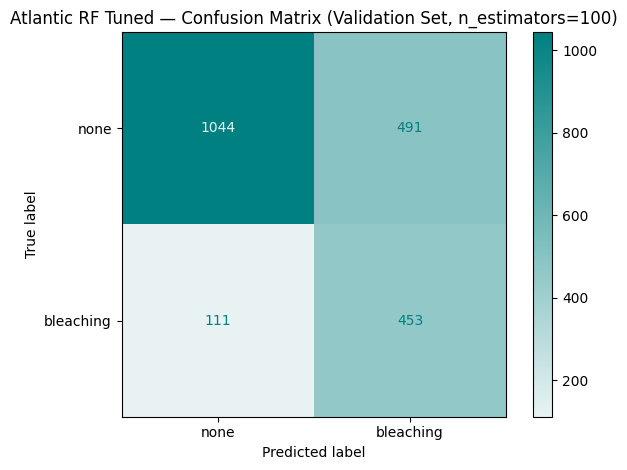

In [18]:
# Confusion matrix for the tuned model (with substrate, n_estimators=100)
# Used here to evaluate tuning impact before the substrate ablation in §5
cm = confusion_matrix(y_val, y_pred_manual_3, labels=['none', 'bleaching'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['none', 'bleaching'])

disp.plot(cmap=sns.light_palette(color_primary, as_cmap=True))
plt.title('Atlantic RF Tuned — Confusion Matrix (Validation Set, n_estimators=100)')
plt.tight_layout()
plt.savefig('../outputs/figures/cm_atlantic_tuned.png', bbox_inches='tight', dpi=150)
plt.show()

### 4.2 Tuning Results: Final Model Selection

| Experiment | max_depth | n_estimators | Recall (bleaching) | Macro F1 |
|---|---|---|---|---|
| Vanilla | 10 | 100 | 0.72 | 0.73 |
| Tuned v1 | 6 | 200 | 0.79 | 0.69 |
| Tuned v2 | 8 | 200 | 0.75 | 0.72 |
| Tuned v3 | 6 | 100 | **0.80** | 0.69 |
| Tuned v4 | 6 | 300 | 0.79 | 0.69 |
| Tuned v5 | 6 | 50  | 0.80 | 0.68 |

**Selected: Tuned v3 — `max_depth=6`, `min_samples_leaf=5`, `n_estimators=100`, `max_features='sqrt'`**

Recall 0.80: the model correctly identifies 8 out of 10 bleaching events 
in the Atlantic validation set. This is a significant improvement over both 
the Atlantic vanilla baseline (0.72) and the global tuned model (0.64).
n_estimators=100 matches n_estimators=300 on recall while being more efficient.

The macro F1 drops from 0.73 to 0.69 compared to the vanilla baseline, 
driven by more false positives on the `none` class. This is the expected 
ecological trade-off: a more sensitive model generates more false alarms 
on healthy reefs, but misses fewer real bleaching events.

## 5. Model Interpretability: SHAP

Again, we use SHAP (SHapley Additive exPlanations) to quantify the contribution of each feature 
to individual model predictions, and explains each prediction individually.

In this project, interpretability is as important as performance: understanding 
which environmental variables drive bleaching predictions helps identify where 
to focus conservation efforts and which regions are more at risk.

We expect thermal stress variables (SSTA, TSA_DHW, DHW) to become prominent in the Atlantic Model, 
together with local physical variables 
(turbidity, windspeed, depth) playing a secondary role.

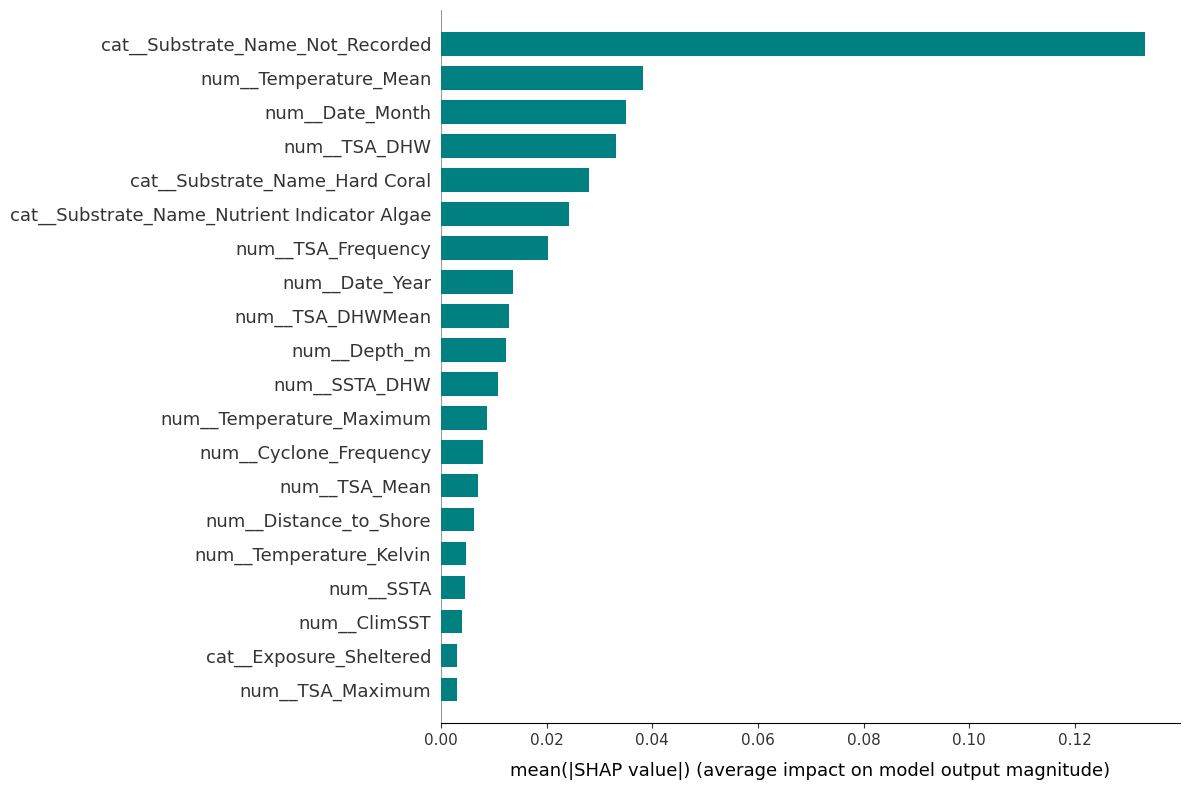

In [19]:
# SHAP explainer on the final Atlantic model
explainer_atl = shap.TreeExplainer(rf_manual_3)

# SHAP values on real validation data (not SMOTE)
shap_sample_atl = X_val_processed[:500]
shap_values_atl = explainer_atl.shap_values(shap_sample_atl)

shap.summary_plot(
    shap_values_atl[:, :, 0],
    shap_sample_atl,
    feature_names=preprocessor_atl.get_feature_names_out(),
    plot_type="bar",
    max_display=20,
    color=color_primary,
    show=False
)
plt.gcf().set_size_inches(12, 8)
plt.xlabel('mean(|SHAP value|) (average impact on model output magnitude)', labelpad=10)
plt.tight_layout()
plt.savefig('../outputs/figures/shap_atl_with_substrate.png', bbox_inches='tight', dpi=150)
plt.show()

In [20]:
# Top 5 features by mean absolute SHAP value
mean_abs_shap_atl = np.abs(shap_values_atl[:, :, 0]).mean(axis=0)
top5_atl = sorted(zip(preprocessor_atl.get_feature_names_out(), mean_abs_shap_atl), key=lambda x: -x[1])[:5]
for name, val in top5_atl:
    print(f"{name}: {val:.4f}")

cat__Substrate_Name_Not_Recorded: 0.1333
num__Temperature_Mean: 0.0383
num__Date_Month: 0.0350
num__TSA_DHW: 0.0332
cat__Substrate_Name_Hard Coral: 0.0281


### 5.1 Substrate Name Ablation

The SHAP plot above shows `cat__Substrate_Name_Not_Recorded` as the dominant feature 
at ~0.10. This is three times larger than `TSA_DHW` (0.030), the primary thermal stress indicator 
in the coral bleaching literature.

`Not_Recorded` is not an ecological variable: it marks observations where substrate type 
was not recorded. Its high SHAP value means the model learned to associate certain data 
collection practices with bleaching outcomes, not the underlying thermal physics.
`Hard Coral` and `Nutrient Indicator Algae` (ranks 5–6) are ecologically interpretable 
but are also correlated with survey methodology, making them potentially confounding.

We retrain the final Atlantic model without `Substrate_Name` to answer two questions:
1. Does recall hold? If yes, the model was not genuinely relying on substrate for prediction.
2. Do thermal variables rise to the top of the SHAP plot, confirming the model now 
   learns thermal physics rather than survey artefacts?

In [21]:
# Substrate ablation: retrain without Substrate_Name.
# Not_Recorded is a data collection artefact (encodes missing survey data, not ecology).
# Hard Coral and Nutrient Indicator Algae are correlated with survey methodology.
# Removing all three forces the model to learn from environmental variables only.

cat_cols_no_sub = ['Realm_Name', 'Exposure']

preprocessor_no_sub = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols_no_sub)
])

X_train_no_sub = preprocessor_no_sub.fit_transform(X_train)
X_val_no_sub = preprocessor_no_sub.transform(X_val)

print(f"Feature count: {X_train_no_sub.shape[1]} (was 28 — removed 3 substrate dummies)")

X_train_no_sub_smote, y_train_no_sub_smote = SMOTE(random_state=42).fit_resample(
    X_train_no_sub, y_train
)

rf_no_sub = RandomForestClassifier(
    max_depth=6,
    min_samples_leaf=5,
    n_estimators=100,
    max_features='sqrt',
    random_state=42
)

rf_no_sub.fit(X_train_no_sub_smote, y_train_no_sub_smote)
y_pred_no_sub = rf_no_sub.predict(X_val_no_sub)

print(classification_report(y_val, y_pred_no_sub))

from sklearn.metrics import recall_score
recall_with = recall_score(y_val, y_pred_manual_3, pos_label='bleaching')
recall_without = recall_score(y_val, y_pred_no_sub, pos_label='bleaching')
print(f"Recall with substrate:    {recall_with:.3f}")
print(f"Recall without substrate: {recall_without:.3f}")
print(f"Delta: {recall_without - recall_with:+.3f}")

Feature count: 23 (was 28 — removed 3 substrate dummies)
              precision    recall  f1-score   support

   bleaching       0.48      0.77      0.59       564
        none       0.89      0.69      0.78      1535

    accuracy                           0.71      2099
   macro avg       0.69      0.73      0.69      2099
weighted avg       0.78      0.71      0.73      2099

Recall with substrate:    0.803
Recall without substrate: 0.775
Delta: -0.028


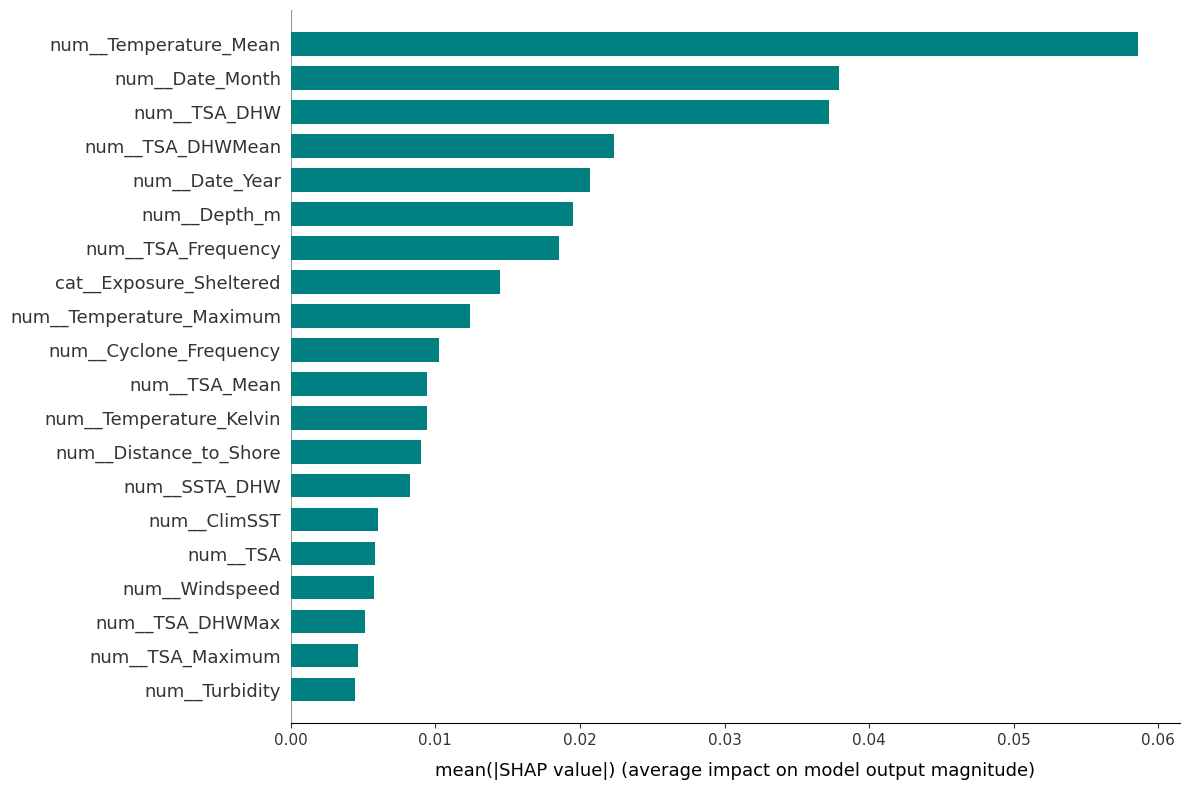

In [22]:
# SHAP on the ablated model - same approach as the full Atlantic model above
explainer_no_sub = shap.TreeExplainer(rf_no_sub)
shap_sample_no_sub = X_val_no_sub[:500]
shap_values_no_sub = explainer_no_sub.shap_values(shap_sample_no_sub)

fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(
    shap_values_no_sub[:, :, 0],
    shap_sample_no_sub,
    feature_names=preprocessor_no_sub.get_feature_names_out(),
    plot_type="bar",
    max_display=20,
    color=color_primary,
    show=False
)
plt.gcf().set_size_inches(12, 8)
plt.xlabel('mean(|SHAP value|) (average impact on model output magnitude)', labelpad=10)
plt.tight_layout()
plt.savefig('../outputs/figures/shap_no_sub.png', bbox_inches='tight', dpi=150)
plt.show()


In [23]:
# Top 5 features by mean absolute SHAP value
mean_abs_shap_no_sub = np.abs(shap_values_no_sub[:, :, 0]).mean(axis=0)
top5_no_sub = sorted(zip(preprocessor_no_sub.get_feature_names_out(), mean_abs_shap_no_sub), key=lambda x: -x[1])[:5]
for name, val in top5_no_sub:
    print(f"{name}: {val:.4f}")

num__Temperature_Mean: 0.0586
num__Date_Month: 0.0379
num__TSA_DHW: 0.0372
num__TSA_DHWMean: 0.0223
num__Date_Year: 0.0207


### 5.1.1 Substrate Ablation: Results

| Model | Recall (bleaching) | Macro F1 |
|---|---|---|
| Atlantic tuned (with substrate) | 0.803 | 0.69 |
| Atlantic no substrate | 0.775 | 0.69 |
| Delta | −0.028 | 0.00 |

**Delta −0.028:** a 2.8pp recall drop. Small enough to confirm the model was not 
genuinely relying on substrate as an ecological signal, but non-negligible. 
`Hard Coral` and `Nutrient Indicator Algae` were contributing some real predictive 
power (likely encoding reef health status), not just artefact.

**SHAP without substrate:** `Temperature_Mean` is now the dominant feature (0.060), 
followed by `Date_Month` (seasonality), `TSA_DHW`, and `Date_Year`. 
The model is now learning thermal physics and seasonality — 
no data collection artefact at the top of the plot.

**Decision:** removing `Substrate_Name` is the scientifically defensible choice 
for the demo. A recall of 0.775 vs 0.803 is a small price for a model that can 
be explained in terms of thermal drivers rather than survey methodology. 
The story for the dashboard: *the Atlantic model correctly identifies ~8 out of 10 
bleaching events using temperature, thermal stress accumulation, and seasonality.*

## 6. Error Analysis

We analyse where the final Atlantic model (without Substrate_Name) fails systematically.
Given that the dataset is Atlantic-only, the geographic breakdown is by Realm rather than Ocean.
The global model had a 0.34 false alarm rate on Atlantic 'none' events: a key benchmark to beat.

In [24]:
# Build a copy of the validation set with predictions attached for error analysis
val_analysis = X_val.copy()
val_analysis['y_true'] = y_val.values
val_analysis['y_pred'] = y_pred_no_sub  # final model: Atlantic RF without Substrate_Name

In [25]:
false_negatives = val_analysis[(val_analysis['y_true'] == 'bleaching') & (val_analysis['y_pred'] == 'none')]
total_bleaching = val_analysis[val_analysis['y_true'] == 'bleaching']

print(f"Missed: {len(false_negatives)}/{len(total_bleaching)} bleaching events (miss rate: {len(false_negatives)/len(total_bleaching):.2f})\n")

fn_by_realm = total_bleaching.groupby('Realm_Name').size().rename('total').to_frame()
fn_by_realm['missed'] = false_negatives.groupby('Realm_Name').size().fillna(0).astype(int)
fn_by_realm['miss_rate'] = (fn_by_realm['missed'] / fn_by_realm['total']).round(2)
print("Miss rate by Realm:\n", fn_by_realm)

print("\nFalse negatives by Year:")
print(false_negatives['Date_Year'].value_counts().sort_index())

Missed: 127/564 bleaching events (miss rate: 0.23)

Miss rate by Realm:
                    total  missed  miss_rate
Realm_Name                                 
Tropical Atlantic    564     127       0.23

False negatives by Year:
Date_Year
2010    54
2011    27
2012    19
2013    20
2014     7
Name: count, dtype: int64


In [26]:
false_positives = val_analysis[(val_analysis['y_true'] == 'none') & (val_analysis['y_pred'] == 'bleaching')]
total_none = val_analysis[val_analysis['y_true'] == 'none']

print(f"False alarms: {len(false_positives)}/{len(total_none)} none events (false alarm rate: {len(false_positives)/len(total_none):.2f})\n")

fp_by_realm = total_none.groupby('Realm_Name').size().rename('total').to_frame()
fp_by_realm['false_alarms'] = false_positives.groupby('Realm_Name').size().fillna(0).astype(int)
fp_by_realm['false_alarm_rate'] = (fp_by_realm['false_alarms'] / fp_by_realm['total']).round(2)
print("False alarm rate by Realm:\n", fp_by_realm)

print("\nFalse positives by Year:")
print(false_positives['Date_Year'].value_counts().sort_index())

False alarms: 474/1535 none events (false alarm rate: 0.31)

False alarm rate by Realm:
                    total  false_alarms  false_alarm_rate
Realm_Name                                              
Tropical Atlantic   1535           474              0.31

False positives by Year:
Date_Year
2010    155
2011     90
2012    149
2013     59
2014     21
Name: count, dtype: int64


### 6.1 Error Analysis Results

**False negatives:** 127/564 bleaching events missed (miss rate: 0.23),
down from 0.39 in the global model. A significant improvement.

**2010 dominates FNs:** 54/127 false negatives fall in 2010 (43%). Consistent with the 
global model pattern: the 2010 post-El Niño thermal signature differs from the 1998 
and 2005 events the model was trained on.

**False alarm rate: 0.31**: marginally lower than the global model's 0.34 on Atlantic 
events. Training on Atlantic data alone reduced false alarms slightly despite the 
more aggressive recall-oriented configuration.

**2010 and 2012 dominate FPs:** 155 and 149 false alarms respectively. 
Both years had moderate thermal anomalies that the model over-interpreted as bleaching risk.

**Overall:** the Atlantic model is a clear improvement over the global baseline.
The 2010 anomaly remains the main structural weakness: it affects both FNs and FPs, 
suggesting the model struggles with moderate, ambiguous thermal events.

## 7. Model Saving

In [27]:
os.makedirs('../models', exist_ok=True)

# Save the final model and its preprocessor together.
# Both are needed at inference time.
# the preprocessor transforms raw input, the model produces the prediction.
joblib.dump(rf_no_sub, '../models/rf_atlantic_model.pkl')
joblib.dump(preprocessor_no_sub, '../models/rf_atlantic_preprocessor.pkl')

print("Saved: rf_atlantic_model.pkl")
print("Saved: rf_atlantic_preprocessor.pkl")

Saved: rf_atlantic_model.pkl
Saved: rf_atlantic_preprocessor.pkl


## 8. Dashboard Data Export

Two lightweight CSVs for the Streamlit dashboard:
- `atlantic_sites_latest.csv`: one row per site (most recent observation), used to populate the map and pre-fill sliders.
- `atlantic_sites_history.csv`: all observations per site, used for the bleaching history panel.


In [28]:
# Creating the dashboard dataframe
dashboard_cols = num_cols + cat_cols_no_sub + ['Latitude_Degrees', 'Longitude_Degrees', 'Bleaching_Category', 'Bleaching_Binary']

df_dash = df_atlantic[dashboard_cols].copy()
print(df_dash.columns.tolist())
print(X_train.columns.tolist())


['Distance_to_Shore', 'Turbidity', 'Cyclone_Frequency', 'Date_Month', 'Date_Year', 'Depth_m', 'ClimSST', 'Temperature_Kelvin', 'Temperature_Mean', 'Temperature_Maximum', 'Windspeed', 'SSTA', 'SSTA_DHW', 'TSA', 'TSA_Maximum', 'TSA_Mean', 'TSA_Frequency', 'TSA_DHW', 'TSA_DHWMax', 'TSA_DHWMean', 'Realm_Name', 'Exposure', 'Latitude_Degrees', 'Longitude_Degrees', 'Bleaching_Category', 'Bleaching_Binary']
['Latitude_Degrees', 'Longitude_Degrees', 'Ocean_Name', 'Realm_Name', 'Distance_to_Shore', 'Exposure', 'Turbidity', 'Cyclone_Frequency', 'Date_Month', 'Date_Year', 'Depth_m', 'Substrate_Name', 'ClimSST', 'Temperature_Kelvin', 'Temperature_Mean', 'Temperature_Maximum', 'Windspeed', 'SSTA', 'SSTA_DHW', 'TSA', 'TSA_Maximum', 'TSA_Mean', 'TSA_Frequency', 'TSA_DHW', 'TSA_DHWMax', 'TSA_DHWMean']


In [29]:
# Creating the csv files for the dashboard
# One row per site: most recent observation
sites_latest = (df_dash
    .sort_values('Date_Year', ascending=False)
    .drop_duplicates(subset=['Latitude_Degrees', 'Longitude_Degrees'])
    .reset_index(drop=True))

# All observations per site, sorted by year
sites_history = (df_dash
    .sort_values(['Latitude_Degrees', 'Longitude_Degrees', 'Date_Year'])
    .reset_index(drop=True))

sites_latest.to_csv('../data/processed/atlantic_sites_latest.csv', index=False)
sites_history.to_csv('../data/processed/atlantic_sites_history.csv', index=False)

print(f"Sites latest: {sites_latest.shape}")
print(f"Sites history: {sites_history.shape}")

Sites latest: (5126, 26)
Sites history: (13087, 26)


In [30]:
# Inspecting the sites_latest dataframe.
sites_latest.head()

,Distance_to_Shore,Turbidity,Cyclone_Frequency,Date_Month,Date_Year,Depth_m,ClimSST,Temperature_Kelvin,Temperature_Mean,Temperature_Maximum,Windspeed,SSTA,SSTA_DHW,TSA,TSA_Maximum,TSA_Mean,TSA_Frequency,TSA_DHW,TSA_DHWMax,TSA_DHWMean,Realm_Name,Exposure,Latitude_Degrees,Longitude_Degrees,Bleaching_Category,Bleaching_Binary
0,42.38,0.0674,54.60,6,2019,11.0,300.95,299.92,300.41,304.39,8.0,-0.21,0.00,-1.96,2.50,-1.46,0.00,0.00,12.30,0.40,Tropical Atlantic,Sheltered,12.4858,-61.4827,none,none
1,64.02,0.1048,52.79,10,2019,9.6,262.15,302.22,300.42,304.23,5.0,0.42,5.28,0.25,2.25,-1.54,2.00,2.25,10.03,0.44,Tropical Atlantic,Exposed,11.3265,-60.5753,none,none
2,1264.04,0.0384,37.81,6,2019,10.0,302.17,301.19,300.93,304.98,7.0,-0.37,2.09,-1.16,2.62,-1.41,0.00,0.00,8.52,0.48,Tropical Atlantic,Exposed,17.9385,-87.9349,none,none
3,60.22,0.0377,61.21,6,2019,10.5,262.15,300.49,300.38,304.52,8.0,0.12,0.71,-1.36,2.67,-1.46,0.29,0.00,7.79,0.25,Tropical Atlantic,Sheltered,17.2125,-62.6548,none,none
4,5928.09,0.0348,61.21,6,2019,13.0,300.83,301.57,300.45,304.79,7.0,1.20,0.00,-0.37,2.84,-1.48,0.00,0.00,6.74,0.16,Tropical Atlantic,Sheltered,17.1861,-62.6806,none,none


In [31]:
# Inspecting the sites_history dataframe.
sites_history.head()

,Distance_to_Shore,Turbidity,Cyclone_Frequency,Date_Month,Date_Year,Depth_m,ClimSST,Temperature_Kelvin,Temperature_Mean,Temperature_Maximum,Windspeed,SSTA,SSTA_DHW,TSA,TSA_Maximum,TSA_Mean,TSA_Frequency,TSA_DHW,TSA_DHWMax,TSA_DHWMean,Realm_Name,Exposure,Latitude_Degrees,Longitude_Degrees,Bleaching_Category,Bleaching_Binary
0,3715.91,0.0821,46.33,4,2005,12.2,299.87,300.60,298.88,303.41,4.0,0.15,0.00,0.12,2.92,-1.59,0.0,0.0,4.60,0.15,Tropical Atlantic,Exposed,-17.9813,-38.6606,none,none
1,3715.91,0.0821,46.33,4,2005,12.2,299.87,300.60,298.88,303.41,4.0,0.15,0.00,0.12,2.92,-1.59,0.0,0.0,4.60,0.15,Tropical Atlantic,Exposed,-17.9813,-38.6606,none,none
2,3715.91,0.0821,46.33,12,2009,11.0,299.75,300.78,298.88,303.41,5.0,1.68,2.57,0.29,2.92,-1.59,2.0,0.0,4.60,0.15,Tropical Atlantic,Exposed,-17.9813,-38.6606,none,none
3,3715.91,0.0821,46.33,12,2009,11.0,299.75,300.78,298.88,303.41,5.0,1.68,2.57,0.29,2.92,-1.59,2.0,0.0,4.60,0.15,Tropical Atlantic,Exposed,-17.9813,-38.6606,none,none
4,2501.13,0.0829,46.33,4,2005,9.0,299.65,301.17,298.91,302.77,3.0,0.77,0.00,0.67,2.26,-1.58,0.0,0.0,5.47,0.17,Tropical Atlantic,Exposed,-17.9774,-38.6714,none,none


In [32]:
# Loading bleaching_clean dataset to merge site names, countries and reef IDs to the dashboard dataframes.
df_clean = pd.read_csv('../data/processed/bleaching_clean.csv', low_memory=False)
df_clean.head()

,Site_ID,Sample_ID,Data_Source,Latitude_Degrees,Longitude_Degrees,Ocean_Name,Reef_ID,Realm_Name,Ecoregion_Name,Country_Name,State_Island_Province_Name,City_Town_Name,Site_Name,Distance_to_Shore,Exposure,Turbidity,Cyclone_Frequency,Date_Day,Date_Month,Date_Year,Depth_m,Substrate_Name,Percent_Cover,Bleaching_Level,Percent_Bleaching,ClimSST,Temperature_Kelvin,Temperature_Mean,Temperature_Minimum,Temperature_Maximum,Temperature_Kelvin_Standard_Deviation,Windspeed,SSTA,SSTA_Standard_Deviation,SSTA_Mean,SSTA_Minimum,SSTA_Maximum,SSTA_Frequency,SSTA_Frequency_Standard_Deviation,SSTA_FrequencyMax,SSTA_FrequencyMean,SSTA_DHW,SSTA_DHW_Standard_Deviation,SSTA_DHWMax,SSTA_DHWMean,TSA,TSA_Standard_Deviation,TSA_Minimum,TSA_Maximum,TSA_Mean,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean,Date,Site_Comments,Sample_Comments,Bleaching_Comments
0,2501,10324336,Donner,23.163,-82.5260,Atlantic,NaN,Tropical Atlantic,Cuba and Cayman Islands,Cuba,Havana,Havana,Puntilla,8519.23,Exposed,0.0287,49.90,15,9,2005,10.00,NaN,NaN,NaN,50.2,301.61,302.05,300.67,296.72,304.69,1.60,8.0,-0.46,1.0,0.0,-3.56,2.24,0.0,3.13,17.00,3.0,0.00,1.63,7.88,0.98,-0.80,1.60,-6.12,1.83,-2.17,0.00,1.09,5.0,0.0,0.00,0.74,7.25,0.18,2005-09-15,NaN,NaN,NaN
1,3467,10324754,Donner,-17.575,-149.7833,Pacific,NaN,Eastern Indo-Pacific,Society Islands French Polynesia,French Polynesia,Society Islands,Moorea,NaN,1431.62,Exposed,0.0262,51.20,15,3,1991,14.00,NaN,NaN,NaN,50.7,262.15,303.30,300.73,297.58,305.01,1.12,2.0,1.29,1.0,0.0,-2.73,3.10,0.5,2.77,13.25,2.0,0.26,1.48,11.41,0.72,1.29,1.12,-4.42,3.00,-1.26,0.25,0.93,4.0,0.0,0.26,0.67,4.65,0.19,1991-03-15,The bleaching does not appear to have gained ...,The bleaching does not appear to have gained ...,NaN
2,1794,10323866,Donner,18.369,-64.5640,Atlantic,NaN,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United Kingdom,British Virgin Islands,Peter Island,Coral Gardens,182.33,Exposed,0.0429,61.52,15,1,2006,7.00,NaN,NaN,NaN,50.9,298.79,299.18,300.32,297.12,304.14,1.22,8.0,0.04,1.0,0.0,-2.92,2.83,16.0,4.52,23.00,3.0,0.00,2.45,16.24,1.26,-2.64,1.22,-4.69,2.31,-1.49,7.00,1.31,7.0,0.0,0.00,1.04,11.66,0.26,2006-01-15,NaN,NaN,NaN
3,8647,10328028,Donner,17.760,-64.5680,Atlantic,NaN,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United States,US Virgin Islands,St. Croix,3219,313.13,Exposed,0.0424,65.39,15,4,2006,9.02,NaN,NaN,NaN,50.9,300.16,299.61,300.38,297.25,304.07,1.19,3.0,-0.07,1.0,0.0,-2.77,2.47,22.0,4.75,24.00,3.0,0.00,2.37,16.73,1.07,-2.27,1.19,-4.63,2.19,-1.49,3.00,0.94,4.0,0.0,0.00,0.75,5.64,0.20,2006-04-15,NaN,NaN,NaN
4,8648,10328029,Donner,17.769,-64.5830,Atlantic,NaN,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United States,US Virgin Islands,St. Croix,3194,792.00,Exposed,0.0424,65.39,15,4,2006,12.50,NaN,NaN,NaN,50.9,300.15,299.70,300.38,296.63,303.76,1.18,3.0,0.00,1.0,0.0,-2.84,2.30,16.0,4.16,20.00,3.0,0.00,2.24,13.86,1.16,-2.19,1.18,-5.25,1.87,-1.50,3.00,1.33,5.0,0.0,0.00,0.92,6.89,0.25,2006-04-15,NaN,NaN,NaN


In [33]:
# Preparing the bleaching_clean.csv for merging
df_clean_names = df_clean[['Reef_ID', 'Site_Name', 'Country_Name', 'Latitude_Degrees', 'Longitude_Degrees']]
df_clean_names.head()


,Reef_ID,Site_Name,Country_Name,Latitude_Degrees,Longitude_Degrees
0,NaN,Puntilla,Cuba,23.163,-82.5260
1,NaN,NaN,French Polynesia,-17.575,-149.7833
2,NaN,Coral Gardens,United Kingdom,18.369,-64.5640
3,NaN,3219,United States,17.760,-64.5680
4,NaN,3194,United States,17.769,-64.5830


In [34]:
# Sanity check of the selected columns
print(df_clean_names.shape)
df_clean_names.isna().sum()

(41361, 5)


Reef_ID              12540
Site_Name            34429
Country_Name             1
Latitude_Degrees         0
Longitude_Degrees        0
dtype: int64

In [35]:
# Dropping duplicates and keeping only unique pairings of Longitude/Latitude
df_clean_names = df_clean_names.drop_duplicates(subset=['Latitude_Degrees', 'Longitude_Degrees'])
df_clean_names.shape

(12323, 5)

In [36]:
# Merging the dashboard datasets with the df_clean_names to match coordinates and names/country of sites
sites_latest = sites_latest.merge(df_clean_names, how='left', on=['Latitude_Degrees', 'Longitude_Degrees'])
sites_history = sites_history.merge(df_clean_names, how='left', on=['Latitude_Degrees', 'Longitude_Degrees'])

print(sites_latest.shape)
print(sites_latest[['Site_Name', 'Country_Name']].isnull().sum())

print(sites_history.shape)
print(sites_history[['Site_Name', 'Country_Name']].isnull().sum())

(5126, 29)
Site_Name       3835
Country_Name       0
dtype: int64
(13087, 29)
Site_Name       9360
Country_Name       0
dtype: int64


In [37]:
# Saving the dataset complete with names
sites_latest.to_csv('../data/processed/atlantic_sites_latest.csv', index=False)
sites_history.to_csv('../data/processed/atlantic_sites_history.csv', index=False)

print(f"Sites latest: {sites_latest.shape}")
print(f"Sites history: {sites_history.shape}")

Sites latest: (5126, 29)
Sites history: (13087, 29)
